# Tarea: Método de la secante

Este método es similar al método N-R, pues utiliza propiedades geométricas de la función. La diferencia es que este método no necesita hacer uso de la derivada de nuestra función. 

Para este método tomamos dos puntos, $x_0$ y $x_1$, y evaluamos ambos puntos en nuestra función. Posteriormente obtenemos una recta que pase por los puntos $(x_0,f(x_0))$ y $(x_1,f(x_1)$. Esta recta será secante a la curva. Analizamos el punto en el que la secante cruza al eje x y llamamos a ese punto $x_2$. Ahora consideramos la secante que cruce a los puntos $(x_1,f(x_1))$ y $(x_2,f(x_2)$ y calculamos el punto en que dicha recta cruza al eje x. Repetimos este proceso hasta encontrr la raíz o acercarnos lo suficiente.

Lo que hace este método es aproximar la tangente por intervalos cada vez más chicos.

Una aproximación de la tangente por medio de la secante está dada por:
$$ f'(x_0) = \frac{f(x_1) - f(x_0)}{x_1 - x_0} $$
Y del método de Newton vimos que la tangente cruza al eje x en:
$$ x_1 = x_0 - \frac{f(x_0)}{f'(x_0)} $$
Sustituyendo la ecuacion 1 en la ecuación 2 llegamos a la expresión:
$$ x_1 = x_0 - \frac{x_1 - x_0}{f(x_1) - f(x_0)}f(x_0) $$

La cual será la expresión del punto que irá iterando en la aproximación.

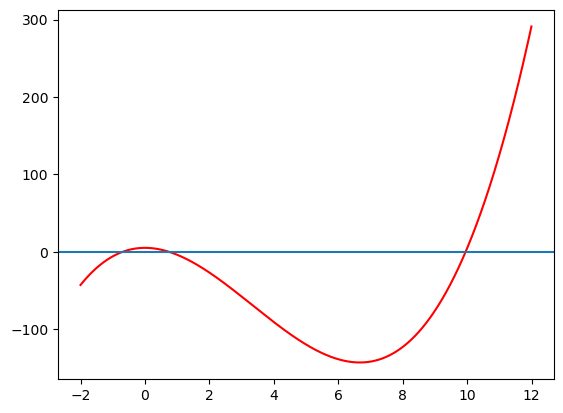

In [2]:
#Definimos nuestra función y la visualizamos
import matplotlib.pyplot as plt
import numpy as np

f = lambda x: x**3 - 10*x**2 + 5

t = np.arange(-2,12,0.01)
plt.plot(t,f(t),'r-')
plt.axhline()
plt.show()

In [3]:
#Definimos la función que contendrá el método numérico
def secante(f,x0,x1,h=1e-6):
    dx = 2*h
    n = 0
    while dx>h:
        x2 = x0 - ((x1-x0)/(f(x1)-f(x0)))*f(x0)
        dx = abs(x0-x1)
        x0 = x1
        x1 = x2
        n += 1
    return [x2,n,dx]

In [4]:
#Ejecutamos algunas veces la función para probarla y calcular las tres raíces de nuestra función
print(secante(f,4,2))
print(secante(f,4,2,1e-10))

[0.7346035077893033, 8, 2.6260388197307805e-08]
[0.7346035077893033, 9, 3.9168668308775523e-13]


In [5]:
secante(f,0,-0.1)

[-0.6840945657036894, 12, 1.3392748465790305e-08]

In [6]:
secante(f,8,10)

[9.949491057914388, 6, 9.021583480262052e-11]

In [9]:
#Creamos la tabla comparativa donde podamos ver el error numérico del método
import pandas as pd
l_secante = []
idx = []
valor_real = 0.7346035077983032 #tolerancia de 10e-17
for i in range(1,12):
    tol = 10**(-i)
    idx.append(tol)
    raiz = secante(f,0,0.8,tol)
    error = (abs(valor_real-raiz[0])/valor_real)*100
    l_secante.append([raiz[0],raiz[1],error])
cols = ['Raíz','Pasos','Error %']
pd.DataFrame(l_secante,index =idx,columns =cols)

,Raíz,Pasos,Error %
1.000000e-01,0.734677,3,1.001427e-02
1.000000e-02,0.734603,4,1.279931e-05
1.000000e-03,0.734604,5,1.786565e-09
1.000000e-04,0.734604,5,1.786565e-09
1.000000e-05,0.734604,6,1.225139e-09
1.000000e-06,0.734604,6,1.225139e-09
1.000000e-07,0.734604,6,1.225139e-09
1.000000e-08,0.734604,7,1.225139e-09
1.000000e-09,0.734604,7,1.225139e-09
1.000000e-10,0.734604,7,1.225139e-09
